## Data Visualization & Visual Study

### Objectives
* Determine average image dimensions across the cherry leaf dataset.
* Calculate and display the **Average Image** and **Variability (Standard Deviation)** for healthy and powdery mildew leaves.
* Compute and visualize the **Visual Difference** between average healthy and average infected leaves.
* Build an **Image Montage** generator function to visually display random samples of healthy and infected leaves side by side.
* Save generated arrays and visualization plots to `outputs/v1/` for integration into the Streamlit dashboard.

### Inputs
* Cleaned and split train dataset in `inputs/cherry_leaves/train/`

### Outputs
* `outputs/v1/mean_healthy.npy`, `outputs/v1/std_healthy.npy`
* `outputs/v1/mean_powdery_mildew.npy`, `outputs/v1/std_powdery_mildew.npy`
* `outputs/v1/avg_var_healthy.png`, `outputs/v1/avg_var_powdery_mildew.png`
* `outputs/v1/avg_diff.png`

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. Resolve Project Root Directory
CURRENT_DIR = os.getcwd()
PROJECT_DIR = os.path.dirname(CURRENT_DIR) if os.path.basename(CURRENT_DIR) == 'jupyter_notebooks' else CURRENT_DIR

# 2. Define Directory Paths
INPUTS_DIR = os.path.join(PROJECT_DIR, 'inputs')
SPLIT_DATA_DIR = os.path.join(INPUTS_DIR, 'cherry_leaves')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs', 'v1')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'validation')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg')

if os.path.exists(TRAIN_DIR):
    LABELS = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    print(f"Project Root: {PROJECT_DIR}")
    print(f"Loaded classes: {LABELS}")
else:
    raise FileNotFoundError(f"Training directory not found at {TRAIN_DIR}")

Project Root: d:\books\code\code-institut\PROJECTS\cherry tree leaves
Loaded classes: ['healthy', 'powdery_mildew']


In [2]:
dim_x, dim_y = [], []

for label in LABELS:
    label_path = os.path.join(TRAIN_DIR, label)
    for img_name in os.listdir(label_path):
        if img_name.lower().endswith(VALID_EXTENSIONS):
            with Image.open(os.path.join(label_path, img_name)) as img:
                w, h = img.size
                dim_x.append(w)
                dim_y.append(h)

# Plot dimension distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dim_x, kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')

sns.histplot(dim_y, kde=True, ax=axes[1], color='salmon', bins=20)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.tight_layout()
dim_plot_path = os.path.join(OUTPUTS_DIR, 'image_dimensions.png')
plt.savefig(dim_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {dim_plot_path}")
print(f"Average Image Dimensions: {int(np.mean(dim_x))}x{int(np.mean(dim_y))} px")

<Figure size 1200x400 with 2 Axes>

Saved: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\image_dimensions.png
Average Image Dimensions: 256x256 px


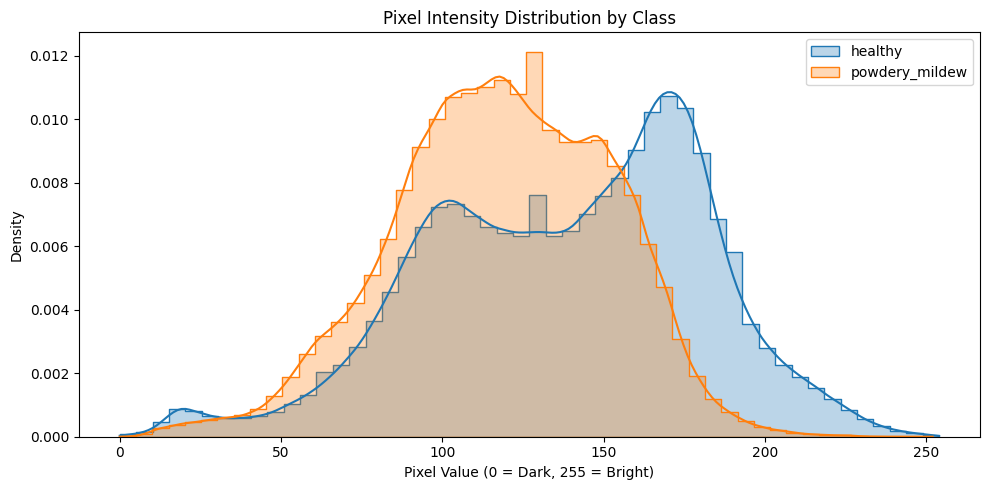

Saved: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\pixel_intensity_histogram.png


In [3]:
random.seed(42)
plt.figure(figsize=(10, 5))

for label in LABELS:
    label_path = os.path.join(TRAIN_DIR, label)
    all_files = [f for f in os.listdir(label_path) if f.lower().endswith(VALID_EXTENSIONS)]
    sample_files = random.sample(all_files, min(50, len(all_files)))
    pixel_vals = []
    
    for fname in sample_files:
        with Image.open(os.path.join(label_path, fname)) as img:
            gray_img = img.convert('L')
            pixel_vals.extend(np.array(gray_img).flatten())
            
    sns.histplot(pixel_vals, label=label, kde=True, stat="density", element="step", alpha=0.3, bins=50)

plt.title('Pixel Intensity Distribution by Class')
plt.xlabel('Pixel Value (0 = Dark, 255 = Bright)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

pixel_plot_path = os.path.join(OUTPUTS_DIR, 'pixel_intensity_histogram.png')
plt.savefig(pixel_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {pixel_plot_path}")

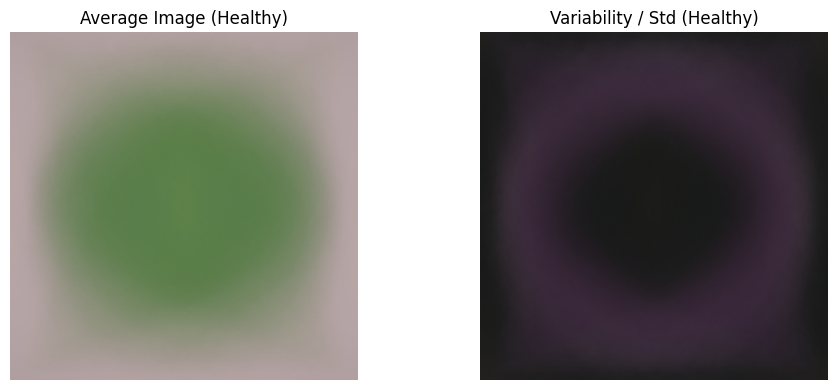

Saved mean/std arrays and plot: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\avg_var_healthy.png


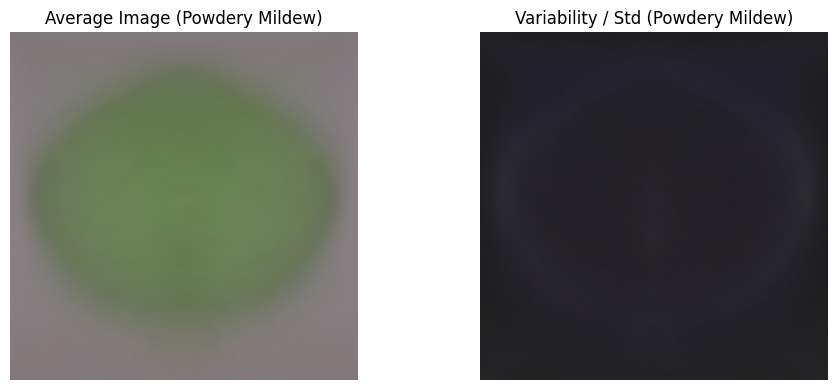

Saved mean/std arrays and plot: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\avg_var_powdery_mildew.png


In [4]:
def compute_class_mean_std(data_dir, labels, target_size=(256, 256)):
    """
    Computes class-wise mean and standard deviation matrices efficiently
    using running sums to avoid memory spikes.
    """
    mean_std_dict = {}

    for label in labels:
        label_path = os.path.join(data_dir, label)
        if not os.path.exists(label_path):
            continue

        files = [f for f in os.listdir(label_path) if f.lower().endswith(VALID_EXTENSIONS)]
        num_imgs = len(files)
        if num_imgs == 0:
            continue

        sum_img = np.zeros((*target_size, 3), dtype=np.float64)
        sum_sq_img = np.zeros((*target_size, 3), dtype=np.float64)

        for fname in files:
            img_path = os.path.join(label_path, fname)
            with Image.open(img_path) as img:
                img_arr = np.array(img.convert('RGB').resize(target_size), dtype=np.float64) / 255.0
                sum_img += img_arr
                sum_sq_img += img_arr ** 2

        mean_img = sum_img / num_imgs
        var_img = (sum_sq_img / num_imgs) - (mean_img ** 2)
        std_img = np.sqrt(np.maximum(var_img, 0))

        mean_std_dict[label] = {'mean': mean_img, 'std': std_img}

    return mean_std_dict

TARGET_SIZE = (256, 256)
mean_std_data = compute_class_mean_std(TRAIN_DIR, LABELS, target_size=TARGET_SIZE)

# Save numpy arrays and generated plots
for label in LABELS:
    if label not in mean_std_data:
        continue
    mean_img = mean_std_data[label]['mean']
    std_img = mean_std_data[label]['std']

    # Save arrays
    np.save(os.path.join(OUTPUTS_DIR, f'mean_{label}.npy'), mean_img)
    np.save(os.path.join(OUTPUTS_DIR, f'std_{label}.npy'), std_img)

    # Plot average and variability
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(mean_img)
    axes[0].set_title(f'Average Image ({label.replace("_", " ").title()})')
    axes[0].axis('off')

    axes[1].imshow(std_img)
    axes[1].set_title(f'Variability / Std ({label.replace("_", " ").title()})')
    axes[1].axis('off')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUTS_DIR, f'avg_var_{label}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved mean/std arrays and plot: {plot_path}")

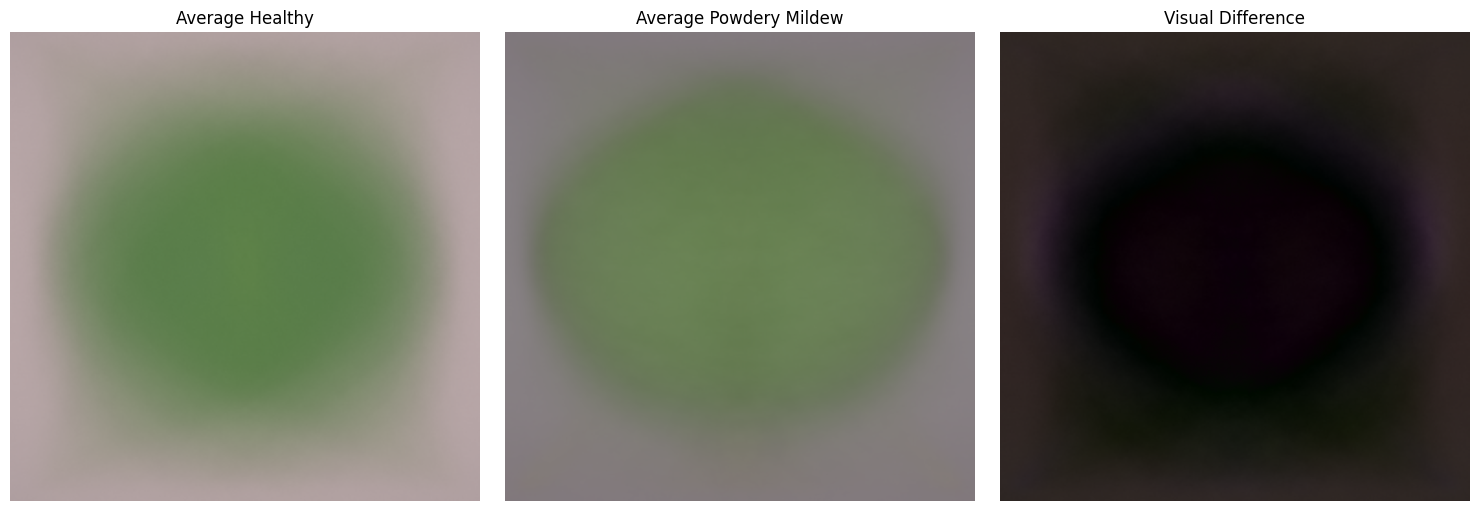

Saved visual difference plot: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\avg_diff.png


In [5]:
if 'healthy' in mean_std_data and 'powdery_mildew' in mean_std_data:
    mean_healthy = mean_std_data['healthy']['mean']
    mean_powdery_mildew = mean_std_data['powdery_mildew']['mean']

    avg_diff = np.abs(mean_healthy - mean_powdery_mildew)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(mean_healthy)
    axes[0].set_title('Average Healthy')
    axes[0].axis('off')

    axes[1].imshow(mean_powdery_mildew)
    axes[1].set_title('Average Powdery Mildew')
    axes[1].axis('off')

    axes[2].imshow(avg_diff)
    axes[2].set_title('Visual Difference')
    axes[2].axis('off')

    plt.tight_layout()
    diff_plot_path = os.path.join(OUTPUTS_DIR, 'avg_diff.png')
    plt.savefig(diff_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved visual difference plot: {diff_plot_path}")
else:
    print("Required labels 'healthy' and 'powdery_mildew' not found for visual difference calculation.")

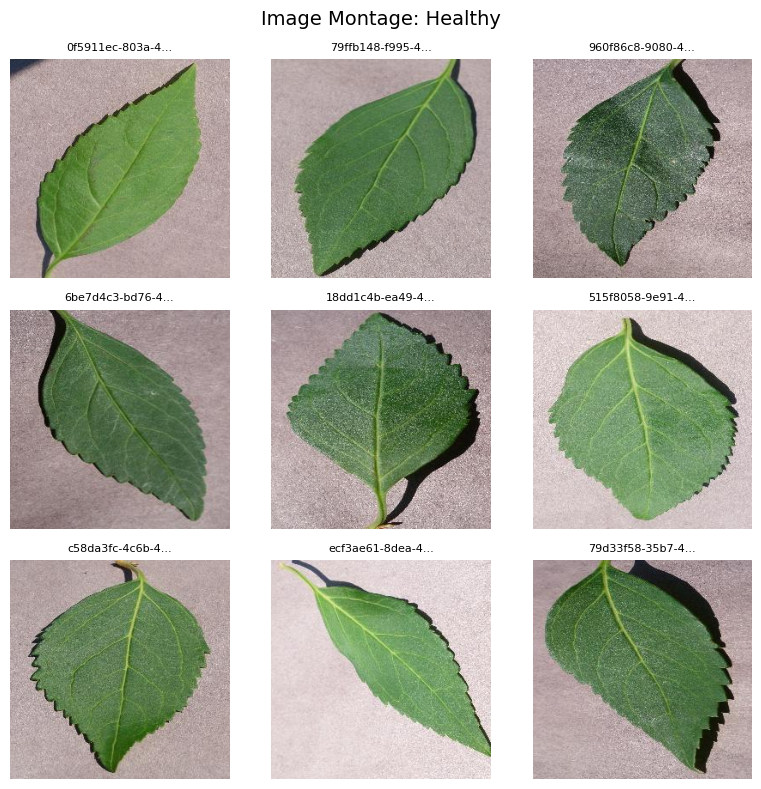

Saved montage: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\montage_healthy.png


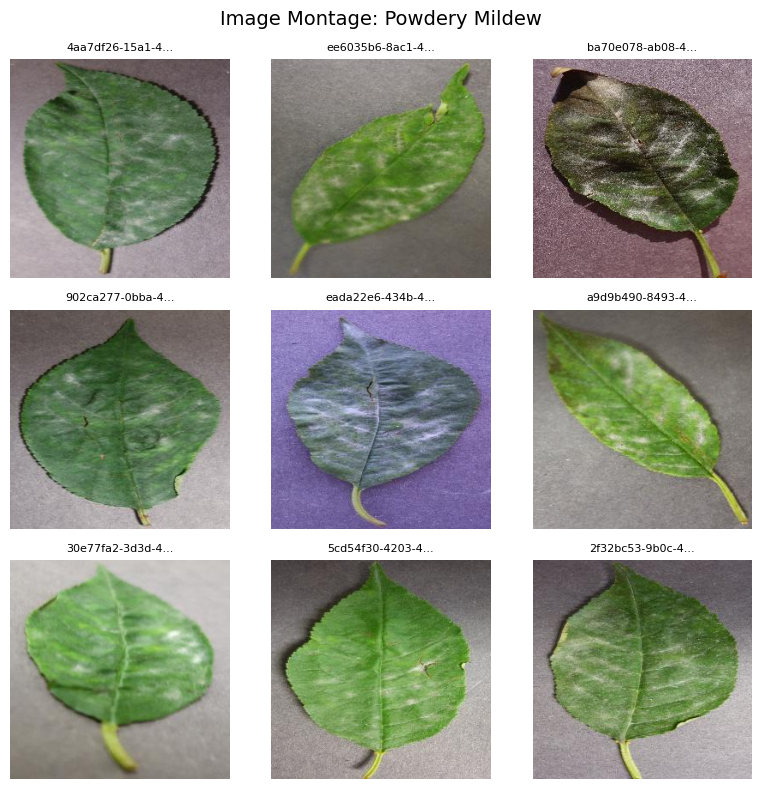

Saved montage: d:\books\code\code-institut\PROJECTS\cherry tree leaves\outputs\v1\montage_powdery_mildew.png


In [6]:
def create_and_save_montage(dir_path, label_to_display, nrows=3, ncols=3, figsize=(8, 8)):
    """
    Creates and saves a grid montage of random image samples for a specified label.
    """
    label_dir = os.path.join(dir_path, label_to_display)
    if not os.path.exists(label_dir):
        print(f"Directory not found: {label_dir}")
        return

    images_list = [f for f in os.listdir(label_dir) if f.lower().endswith(VALID_EXTENSIONS)]
    num_images = nrows * ncols

    if len(images_list) < num_images:
        print(f"Insufficient images ({len(images_list)}) for a {nrows}x{ncols} montage.")
        return

    selected_images = random.sample(images_list, num_images)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.suptitle(f"Image Montage: {label_to_display.replace('_', ' ').title()}", fontsize=14)

    # Flatten axes array for safe indexing
    axes_flat = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

    for idx, img_name in enumerate(selected_images):
        ax = axes_flat[idx]
        img_path = os.path.join(label_dir, img_name)
        with Image.open(img_path) as img:
            ax.imshow(img)
            ax.set_title(img_name[:15] + '...', fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    montage_path = os.path.join(OUTPUTS_DIR, f'montage_{label_to_display}.png')
    plt.savefig(montage_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved montage: {montage_path}")

# Generate and save montages for all classes
for label in LABELS:
    create_and_save_montage(TRAIN_DIR, label, nrows=3, ncols=3)